In [58]:
import pandas as pd
import numpy as np 

import os, sys
sys.path.append(f"../../")

import matplotlib.pyplot as plt
import matplotlib.dates as mdates 


In [45]:
import data.data_utils as data_utils

In [46]:
case_counts = pd.read_csv("../../data/preprocessed/case_counts.csv")

In [60]:
y_name, t_dates, t_normalized, ys = data_utils.load_data("North_South", "both", 
                                 None, "flow", "N1", 
                                 False, True)

ww = pd.DataFrame(t_dates, columns=["date"])
ww[y_name] = ys

In [61]:
case_counts["Meldedatum"] = pd.to_datetime(case_counts["Meldedatum"], format="%Y-%m-%d")
case_counts = case_counts.groupby("Meldedatum")[["N", "N_7d"]].sum().reset_index()

In [62]:
ww["date"] = pd.to_datetime(ww["date"], format="%Y-%m-%d")
df = ww.merge(case_counts, left_on="date", right_on="Meldedatum", how="inner")

In [63]:
df

,date,flow_normalized_COVID_N1,Meldedatum,N,N_7d
0,2022-03-02,116900.155802,2022-03-02,439,805.0
1,2022-03-07,124503.981278,2022-03-07,492,3020.0
2,2022-03-09,124360.657621,2022-03-09,581,3847.0
3,2022-03-14,84517.477347,2022-03-14,585,3750.0
4,2022-03-16,130121.968986,2022-03-16,668,3922.0
...,...,...,...,...,...
156,2024-01-29,8264.439840,2024-01-29,4,18.0
157,2024-01-31,38601.022572,2024-01-31,4,9.0
158,2024-02-05,13511.096937,2024-02-05,1,8.0
159,2024-02-15,47850.183387,2024-02-15,1,4.0


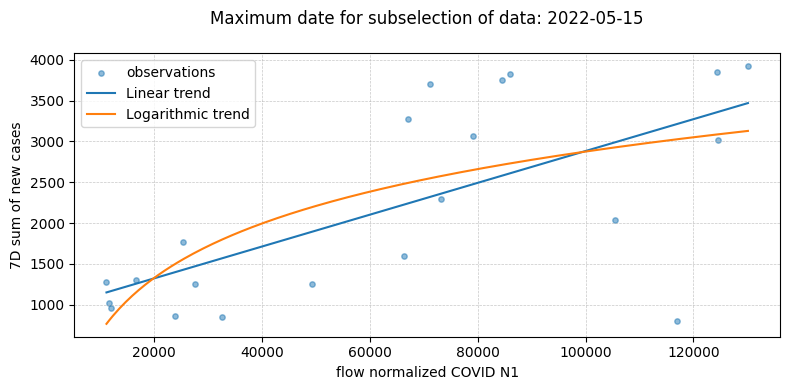

In [ ]:
max_date = "2022-05-15"
df_sub = df[df["date"] <= max_date].copy()

# Extract variables
x = df_sub[y_name].values
y = df_sub["N_7d"].values

# Linear regression (y = a + b*x)
slope_lin, intercept_lin = np.polyfit(x, y, 1)

# Logarithmic regression (y = a + b*log(x)), exclude non‑positive x
slope_log, intercept_log = np.polyfit(np.log(x), y, 1)

# Prediction range (avoid zero for log)
x_range = np.linspace(x.min(), x.max(), 200)
y_pred_lin = intercept_lin + slope_lin * x_range
y_pred_log = intercept_log + slope_log * np.log(x_range)

# Plot
plt.figure(figsize=(8, 4), dpi=100)
plt.scatter(x, y, s=15, alpha=0.5, label='observations')
plt.plot(x_range, y_pred_lin, label='Linear trend')
plt.plot(x_range, y_pred_log, label='Logarithmic trend')
plt.ylabel("7D sum of new cases")
plt.xlabel(y_name.replace('_', ' '))
plt.title(f"Maximum date for subselection ofx data: {max_date}\n")
plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


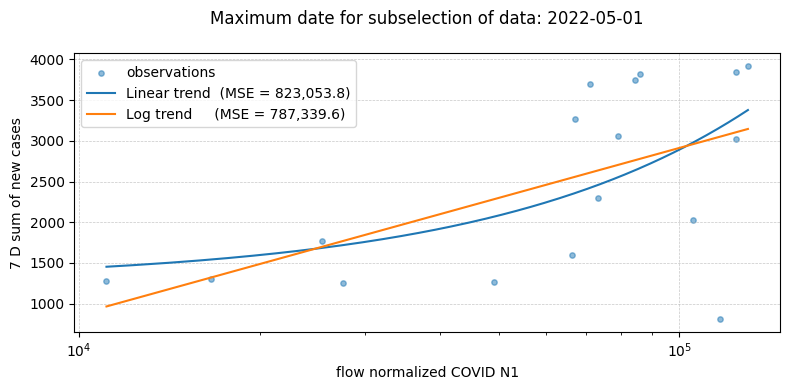

In [81]:

max_date = "2022-05-01"
df_sub = df[df["date"] <= max_date].copy()

x = df_sub[y_name].values
y = df_sub["N_7d"].values

# Linear regression (y = a + b*x)
slope_lin, intercept_lin = np.polyfit(x, y, 1)

# Logarithmic regression (y = a + b*log(x))
mask = x > 0
slope_log, intercept_log = np.polyfit(np.log(x[mask]), y[mask], 1)

y_pred_lin_obs = intercept_lin + slope_lin * x
mse_lin = np.mean((y - y_pred_lin_obs) ** 2)

y_pred_log_obs = intercept_log + slope_log * np.log(x[mask])
mse_log = np.mean((y[mask] - y_pred_log_obs) ** 2)

x_range = np.linspace(x[mask].min(), x.max(), 200)
y_pred_lin = intercept_lin + slope_lin * x_range
y_pred_log = intercept_log + slope_log * np.log(x_range)

plt.figure(figsize=(8, 4), dpi=100)
plt.scatter(x, y, s=15, alpha=0.5, label="observations")
plt.plot(x_range, y_pred_lin, label=f"Linear trend  (MSE = {mse_lin:,.1f})")
plt.plot(x_range, y_pred_log, label=f"Log trend     (MSE = {mse_log:,.1f})")
plt.ylabel("7 D sum of new cases")
plt.xlabel(y_name.replace('_', ' '))
plt.xscale('log')
plt.title(f"Maximum date for subselection of data: {max_date}\n")
plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


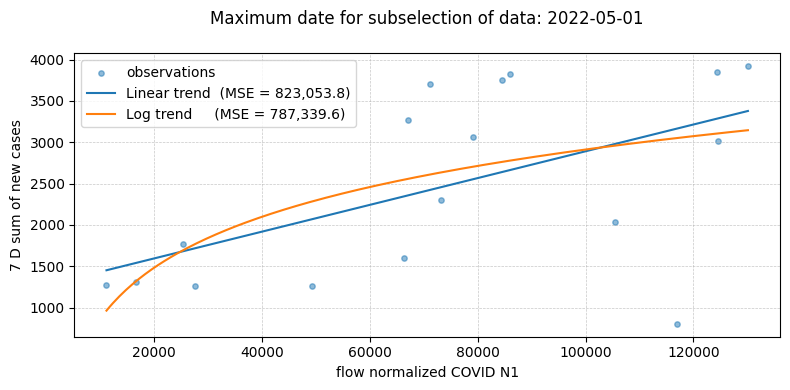

In [80]:

max_date = "2022-05-01"
df_sub = df[df["date"] <= max_date].copy()

x = df_sub[y_name].values
y = df_sub["N_7d"].values

# Linear regression (y = a + b*x)
slope_lin, intercept_lin = np.polyfit(x, y, 1)

# Logarithmic regression (y = a + b*log(x))
mask = x > 0
slope_log, intercept_log = np.polyfit(np.log(x[mask]), y[mask], 1)

y_pred_lin_obs = intercept_lin + slope_lin * x
mse_lin = np.mean((y - y_pred_lin_obs) ** 2)

y_pred_log_obs = intercept_log + slope_log * np.log(x[mask])
mse_log = np.mean((y[mask] - y_pred_log_obs) ** 2)

x_range = np.linspace(x[mask].min(), x.max(), 200)
y_pred_lin = intercept_lin + slope_lin * x_range
y_pred_log = intercept_log + slope_log * np.log(x_range)

plt.figure(figsize=(8, 4), dpi=100)
plt.scatter(x, y, s=15, alpha=0.5, label="observations")
plt.plot(x_range, y_pred_lin, label=f"Linear trend  (MSE = {mse_lin:,.1f})")
plt.plot(x_range, y_pred_log, label=f"Log trend     (MSE = {mse_log:,.1f})")
plt.ylabel("7 D sum of new cases")
plt.xlabel(y_name.replace('_', ' '))
plt.title(f"Maximum date for subselection of data: {max_date}\n")
plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()
